In [1]:
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from pathlib import Path

/home/jacob253/miniconda3/envs/bundling/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = "3figures"


In [3]:
paths = sorted(Path(os.path.join(data_path, "data")).glob("s1*.jpg"))  # s1 images show yoda and bulldog s2 image show bulldog and rabbit

imgs = np.stack([
    np.array(Image.open(p).convert("RGB"))
    for p in paths
])
print(imgs.shape)

(8100, 240, 320, 3)


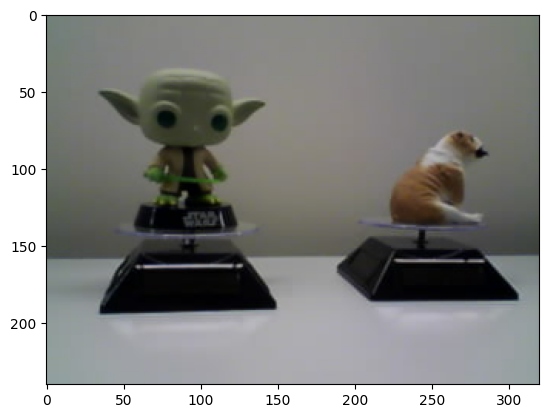

In [4]:
plt.imshow(imgs[0])

In [192]:
imgs_flat = imgs.reshape(len(imgs), -1)
pca_embedder = PCA(n_components=10)
pca = pca_embedder.fit_transform(imgs_flat)

In [193]:
umap_embedding = umap.UMAP(n_components=3, min_dist=0.8).fit_transform(pca)

In [5]:
pca = np.load("yoda_bulldog_pca50.npy")


In [13]:
from sklearn.metrics import pairwise_distances
from projector import MDSTorusProjector

D = pairwise_distances(pca)
D /= (4*np.max(D))
embd = MDSTorusProjector().fit_transform(D)

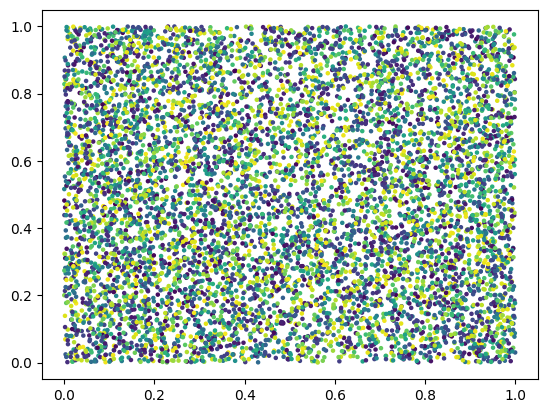

In [14]:
fig, ax = plt.subplots()
plt.scatter(embd[:,0], embd[:,1],c=pca[:,2],s=5)

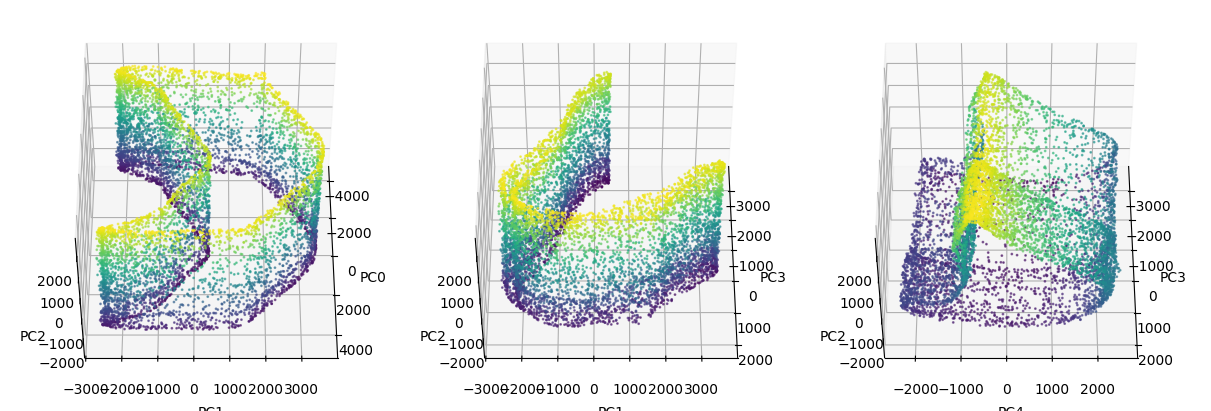

In [194]:
fig, ax = plt.subplots(1, 3, figsize=(12, 7), subplot_kw={"projection": "3d"}, constrained_layout=True)

base_elev = 50
base_azim = 0  # choose what looks good for panel 0

for i in range(3):

    ax[i].scatter(
        *np.roll(pca[:, i:i+3], i ,axis=1).T,
        c=pca[:, 2], #np.arange(len(imgs)),
        s=1,          # marker size
        alpha=0.6
    )
    ax[i].view_init(elev=base_elev, azim=base_azim )
    pc_order = np.roll(np.arange(i, i+3),i)
    ax[i].set_xlabel(f"PC{pc_order[0]}")
    ax[i].set_ylabel(f"PC{pc_order[1]}")
    ax[i].set_zlabel(f"PC{pc_order[2]}")

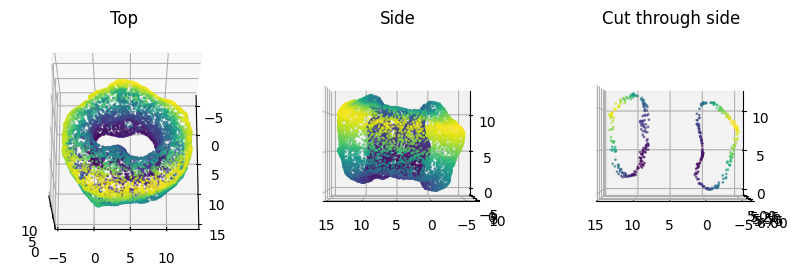

In [195]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6), subplot_kw={"projection": "3d"})

elevs = [70, 0, 0]
azims = [0, 90, 90]

labels = ["Top", "Side", "Cut through side"]

for i in range(3):

    mask = np.ones(len(umap_embedding), dtype=bool)
    if i > 1:
        mask = (umap_embedding[:, 1] >5) * (umap_embedding[:, 1] < 6)

    ax[i].scatter(
        *umap_embedding[mask].T,
        c=pca[:, 2][mask],
        s=1,          # marker size
        alpha=0.6
    )
    ax[i].view_init(elev=elevs[i], azim=azims[i])
    ax[i].set_title(labels[i])